# UK sterling transition, 1900-1980

**First transition-scale test of the changing-world-order umbrella thesis (issue #52, Phase A).**

The umbrella thesis claims the US is heading toward a reserve-currency-issuer debt-cycle resolution whose historically dominant form is mode-4 (monetization). The only prior analogous transition with reasonable data is the UK losing sterling reserve status, roughly 1900-1980. If the umbrella is roughly right, we should see a recognizable pattern in UK data: fiscal stress accumulating from the world wars, deflation-then-inflation through the interwar crises, gilt underperformance in the 1970s, and sterling real depreciation extending through the 1949 and 1967 devaluations and the 1976 IMF bailout.

This notebook plots the series fetched from the Bank of England's *A Millennium of Macroeconomic Data* (v3.1) against a timeline of the anchoring events, and ends with a qualitative call on whether the Dalio fiscal-deterioration → monetization pattern is visible.

All data is annual. Narrative commentary is interleaved with plots; this is not a dashboard.

Companion reading:
- `specs/theses/changing-world-order/README.md` — the umbrella thesis
- `specs/theses/changing-world-order/us-fiscal-deterioration.md` — the central implication (this evidence log gets appended at the end)
- `specs/theses/changing-world-order/backtest-sample-scope.md` — why cross-national historical data is required
- `specs/theses/changing-world-order/dalio-principles.md` §9 (cross-national methodology), §10 (base-rate framing)

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.data_fetcher_uk import load_series as load_uk

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 4.5)
plt.rcParams['figure.dpi'] = 110

# Anchoring events the project cares about for the sterling transition
EVENTS = [
    ('1914-07-28', 'WW1'),
    ('1925-04-28', 'Gold standard return (Churchill)'),
    ('1931-09-21', 'Sterling crisis / abandoning gold'),
    ('1939-09-01', 'WW2'),
    ('1944-07-22', 'Bretton Woods'),
    ('1949-09-18', 'Sterling devaluation'),
    ('1956-11-05', 'Suez crisis'),
    ('1967-11-18', 'Sterling devaluation'),
    ('1976-12-15', 'IMF bailout'),
]

IMAGE_DIR = Path('../docs/research/images')
IMAGE_DIR.mkdir(parents=True, exist_ok=True)

def add_events(ax, events=EVENTS, ymax_frac=0.92):
    ymin, ymax = ax.get_ylim()
    for date, label in events:
        x = pd.Timestamp(date)
        ax.axvline(x, color='k', alpha=0.22, linewidth=0.8, linestyle='--')
        ax.annotate(
            label, xy=(x, ymin + (ymax - ymin) * ymax_frac),
            xytext=(3, 0), textcoords='offset points',
            fontsize=7.5, alpha=0.75, rotation=90, va='top',
        )
    ax.set_ylim(ymin, ymax)


def window(series: pd.Series, start: str = '1900', end: str = '1980') -> pd.Series:
    return series.loc[start:end]


print('Loaded helpers and events.')

Loaded helpers and events.


In [2]:
# Load every active UK series
SERIES_IDS = [
    'uk_public_debt_gdp', 'uk_public_receipts_gdp', 'uk_public_spending_gdp', 'uk_public_deficit_gdp',
    'uk_bank_rate', 'uk_cpi', 'uk_cpi_inflation', 'uk_broad_money', 'uk_monetary_base',
    'uk_boe_balance_sheet_gdp', 'uk_10yr_gilt', 'uk_consols_yield',
    'uk_share_prices', 'uk_usd_gbp_rate', 'uk_real_usd_gbp_rate', 'uk_nominal_eri', 'uk_real_eri',
    'uk_house_prices', 'uk_agricultural_land', 'uk_oil_price_usd',
    'uk_real_gdp', 'uk_real_gdp_growth', 'uk_nominal_gdp',
    'uk_unemployment_rate', 'uk_current_account_gdp', 'uk_trade_deficit_gdp',
]

data = {}
for sid in SERIES_IDS:
    df = load_uk(sid)
    # load_series returns a single-column DataFrame; squeeze to Series
    data[sid] = df.iloc[:, 0]

print('Loaded {} series.'.format(len(data)))
print('\nCoverage over 1900-1980 transition window:')
for sid, s in data.items():
    w = window(s)
    print(f'  {sid:30s}: {len(w)} annual obs')

Loaded 26 series.

Coverage over 1900-1980 transition window:
  uk_public_debt_gdp            : 81 annual obs
  uk_public_receipts_gdp        : 81 annual obs
  uk_public_spending_gdp        : 81 annual obs
  uk_public_deficit_gdp         : 81 annual obs
  uk_bank_rate                  : 81 annual obs
  uk_cpi                        : 81 annual obs
  uk_cpi_inflation              : 81 annual obs
  uk_broad_money                : 81 annual obs
  uk_monetary_base              : 81 annual obs
  uk_boe_balance_sheet_gdp      : 81 annual obs
  uk_10yr_gilt                  : 52 annual obs
  uk_consols_yield              : 81 annual obs
  uk_share_prices               : 81 annual obs
  uk_usd_gbp_rate               : 81 annual obs
  uk_real_usd_gbp_rate          : 81 annual obs
  uk_nominal_eri                : 81 annual obs
  uk_real_eri                   : 81 annual obs
  uk_house_prices               : 81 annual obs
  uk_agricultural_land          : 70 annual obs
  uk_oil_price_usd        

## 1. Fiscal trajectory — debt, deficit, and the tax-vs-spending balance

The Dalio pattern predicts fiscal deterioration as the first symptom: war-era debt-to-GDP spikes, deficit persistence through peacetime, and pressure on receipts that the state struggles to reduce proportionally. If the mechanism works, we should see the UK debt-to-GDP ratio rachet up through the two world wars, only partially unwinding between them, and the primary balance persistently deficient during the post-WW2 welfare-state buildout.

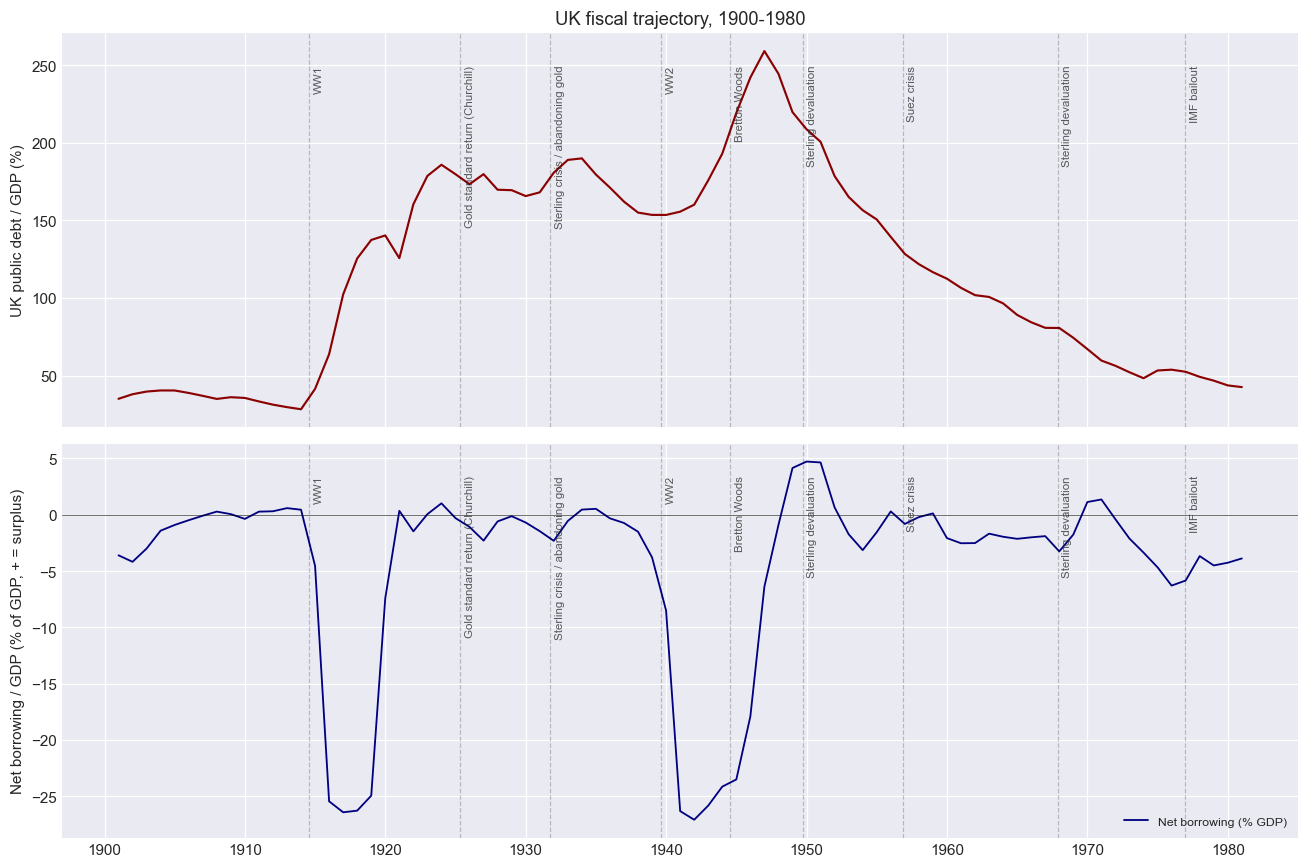

In [3]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

debt = window(data['uk_public_debt_gdp'])
ax1.plot(debt.index, debt.values, color='darkred', linewidth=1.4)
ax1.set_ylabel('UK public debt / GDP (%)')
ax1.set_title('UK fiscal trajectory, 1900-1980')
add_events(ax1)

deficit = window(data['uk_public_deficit_gdp'])
ax2.plot(deficit.index, deficit.values, color='navy', linewidth=1.2, label='Net borrowing (% GDP)')
ax2.axhline(0, color='k', linewidth=0.6, alpha=0.6)
ax2.set_ylabel('Net borrowing / GDP (% of GDP, + = surplus)')
ax2.legend(loc='lower right', fontsize=8)
add_events(ax2)

plt.tight_layout()
fig.savefig(IMAGE_DIR / 'uk_fiscal_trajectory.png', bbox_inches='tight', dpi=140)
plt.show()

**What the data shows.** UK public debt/GDP runs above ~30% from 1900, spikes into ~150% after WW1, partially deleverages through the 1920s (but stays elevated through the Depression and gold-standard return), and then *more than doubles* through WW2 to a peak of ~260% in 1947. The deleveraging from 1947 to 1980 is real but slow — ~25 percentage points of GDP reduction over three decades. By contrast the deficit series is much noisier: peacetime deficits are modest, but the two wars dominate. The 1970s show a persistent deficit pattern re-emerging, consistent with the era's end in the IMF bailout.

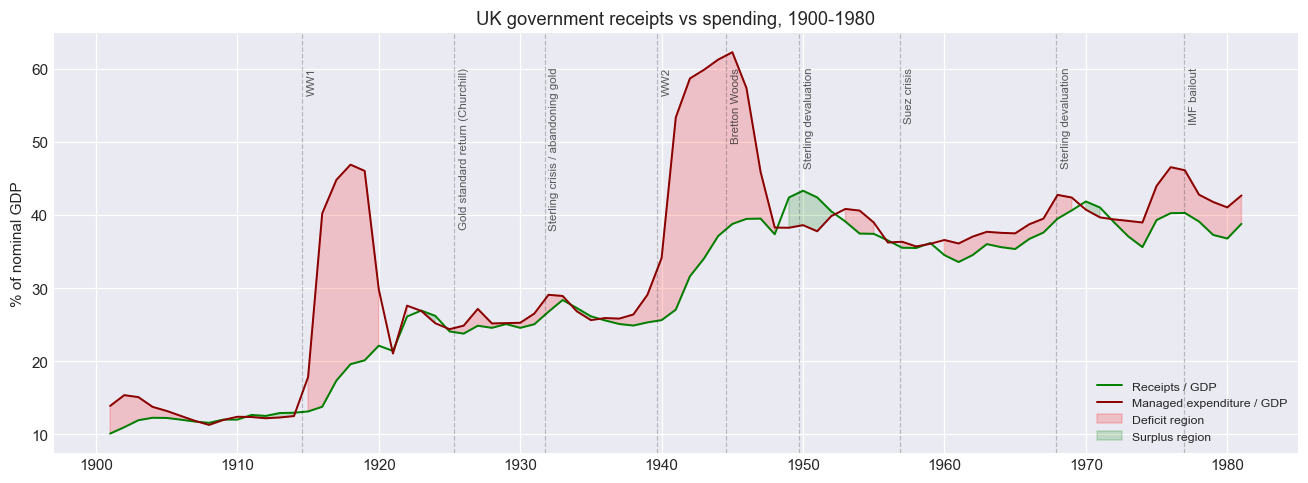

In [4]:
fig, ax = plt.subplots(figsize=(12, 4.5))
recs = window(data['uk_public_receipts_gdp'])
spend = window(data['uk_public_spending_gdp'])
ax.plot(recs.index, recs.values, color='green', linewidth=1.3, label='Receipts / GDP')
ax.plot(spend.index, spend.values, color='darkred', linewidth=1.3, label='Managed expenditure / GDP')
ax.fill_between(recs.index, recs.values, spend.values,
                where=spend.values > recs.values, color='red', alpha=0.18, label='Deficit region')
ax.fill_between(recs.index, recs.values, spend.values,
                where=spend.values <= recs.values, color='green', alpha=0.18, label='Surplus region')
ax.set_ylabel('% of nominal GDP')
ax.set_title('UK government receipts vs spending, 1900-1980')
ax.legend(loc='lower right', fontsize=8)
add_events(ax)
plt.tight_layout()
plt.show()

**What the data shows.** The receipts–spending gap is the clearer fiscal-stress signal. Through both wars the gap is enormous (spending >50% of GDP while receipts struggle to exceed 40%). Between the wars, receipts do catch up to spending. Post-WW2, the *level* of government relative to GDP stays roughly 40% — the welfare state is permanent — but the gap narrows. The 1970s widen the gap again, ending in the IMF crisis.

Notable: this is NOT the US pattern where a structural deficit persists in peacetime across multiple decades. UK peacetime deficits before 1970 are modest; UK fiscal stress in this period is war-driven first, policy-driven second. That matters for the comparison to the modern US case, which has no war explaining its ~6% structural deficit.

## 2. Prices, money, and the Bank Rate

The Dalio monetization mechanism predicts that fiscal pressure eventually forces the central bank to accommodate, either through direct balance-sheet expansion or through low policy rates that keep debt-service affordable. The UK's experience is a mix: gold-standard adherence (1925-1931) forced deflationary discipline; post-WW2 broke that; the 1970s produced the most pronounced inflation of the sample.

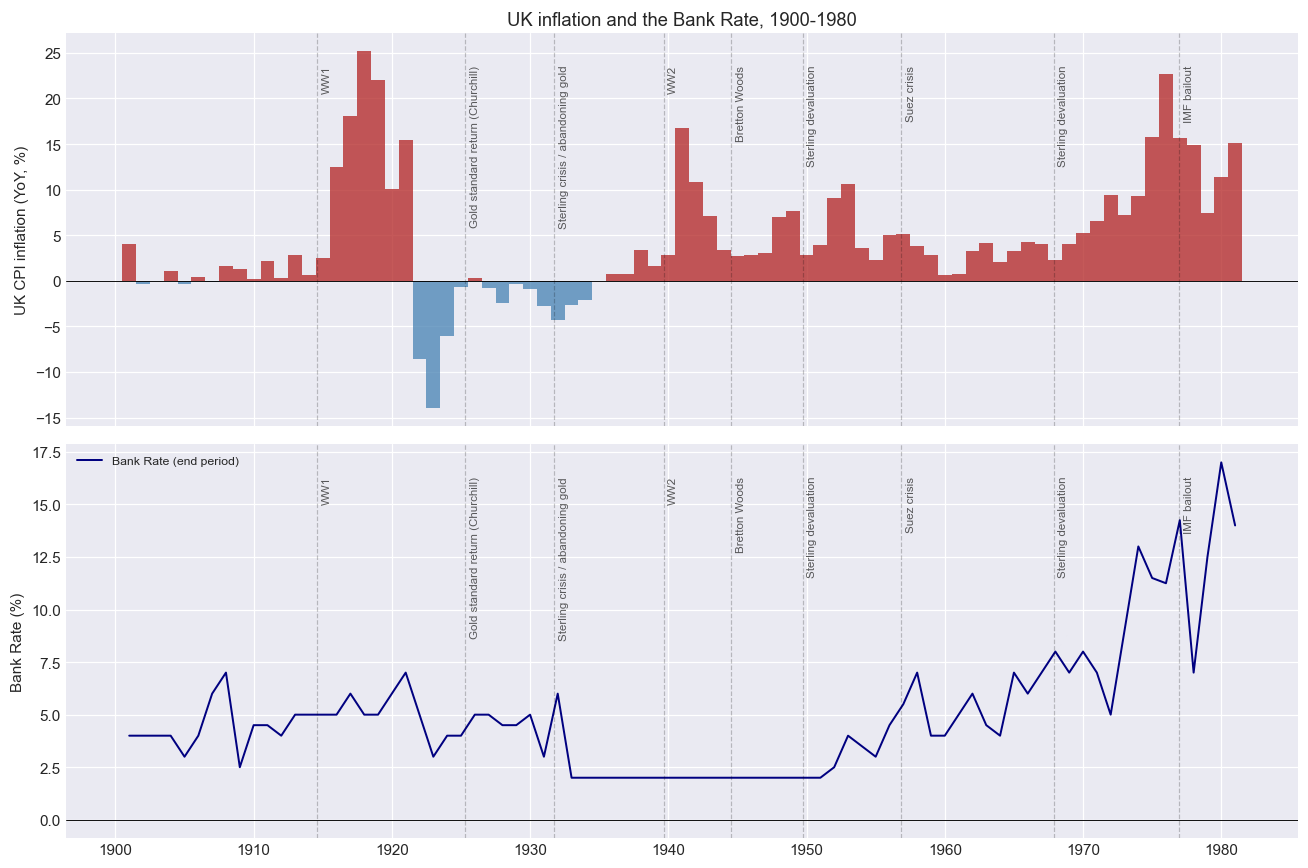

In [5]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

infl = window(data['uk_cpi_inflation'])
ax1.bar(infl.index, infl.values, width=365, color=np.where(infl.values >= 0, 'firebrick', 'steelblue'), alpha=0.75)
ax1.axhline(0, color='k', linewidth=0.6)
ax1.set_ylabel('UK CPI inflation (YoY, %)')
ax1.set_title('UK inflation and the Bank Rate, 1900-1980')
add_events(ax1)

rate = window(data['uk_bank_rate'])
ax2.plot(rate.index, rate.values, color='navy', linewidth=1.3, label='Bank Rate (end period)')
ax2.set_ylabel('Bank Rate (%)')
ax2.axhline(0, color='k', linewidth=0.6)
ax2.legend(loc='upper left', fontsize=8)
add_events(ax2)

plt.tight_layout()
fig.savefig(IMAGE_DIR / 'uk_inflation_bank_rate.png', bbox_inches='tight', dpi=140)
plt.show()

**What the data shows.** Three inflation regimes are visible:

1. **Pre-1914 (classical gold standard):** near-zero inflation on average, as expected under fixed specie redemption.
2. **1915-1920:** massive war inflation (~25% in 1917), then a brutal 1920-1922 deflation (prices fall ~15%+ per year) as the UK attempted to restore pre-war parity. Churchill's 1925 return to gold locked in overvaluation.
3. **1931 onward:** after abandoning gold, inflation becomes episodic rather than absent. The 1940s and especially the 1970s show persistent positive inflation. The 1975 peak (~24%) is close to the 1917 war-inflation peak, but this time in peacetime.

The Bank Rate pattern tells the story from the other side. Pre-WW2 the Bank Rate is a classical monetary-stabilization tool, responsive to gold flows and discount-market stress. Post-WW2 the Bank Rate is pinned at ~2% throughout the 1940s — explicit financial repression, keeping the real debt burden manageable by holding nominal rates below inflation. The rate rises in the 1960s-70s but *lags* inflation badly; real rates are deeply negative for much of this window.

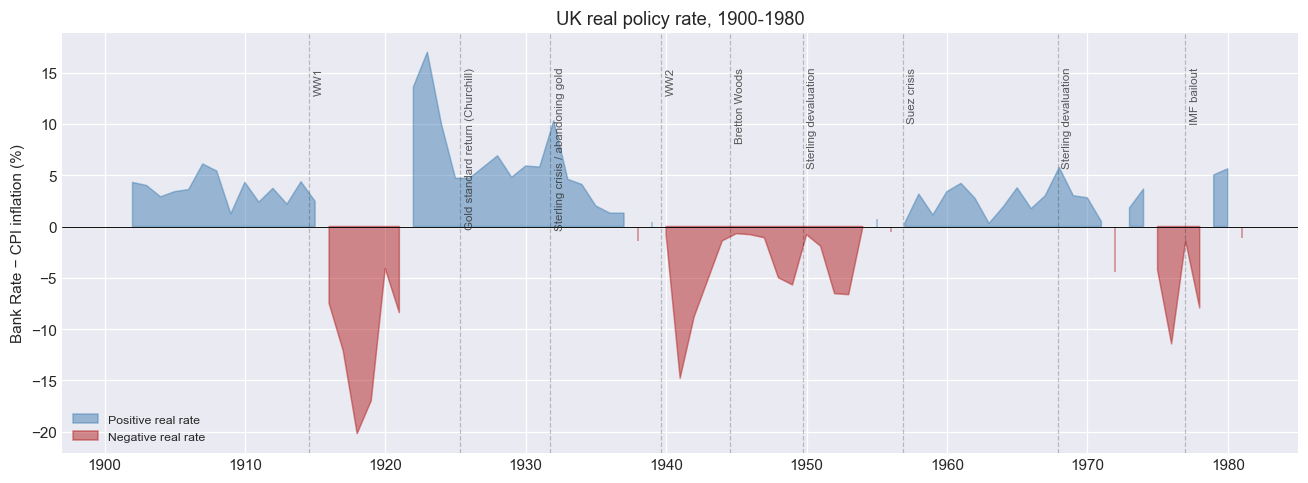

In [6]:
# Real rate = Bank Rate - CPI inflation, a rough monetization-stress proxy
real_rate = (data['uk_bank_rate'] - data['uk_cpi_inflation']).dropna()
real_rate = window(real_rate)

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.fill_between(real_rate.index, real_rate.values, 0,
                where=real_rate.values >= 0, color='steelblue', alpha=0.5, label='Positive real rate')
ax.fill_between(real_rate.index, real_rate.values, 0,
                where=real_rate.values < 0, color='firebrick', alpha=0.5, label='Negative real rate')
ax.axhline(0, color='k', linewidth=0.6)
ax.set_ylabel('Bank Rate − CPI inflation (%)')
ax.set_title('UK real policy rate, 1900-1980')
ax.legend(loc='lower left', fontsize=8)
add_events(ax)
plt.tight_layout()
plt.show()

**What the data shows.** Real rates are substantially negative in three distinct windows: 1915-1920 (war inflation exceeding policy rate), 1940-1948 (post-WW2 financial repression), and roughly 1972-1979 (the stagflation / IMF-bailout run-up). These are *exactly* the windows where the fiscal arithmetic most needed accommodation. This is monetization-in-effect even without the Bank of England formally purchasing a large share of gilts: by holding the Bank Rate below inflation, real debt burdens erode at a rate equal to the negative real-rate integral.

This is a key piece of evidence *for* the Dalio mechanism. The UK did not default, did not restructure, and did not formally monetize via large-scale QE-style purchases. But it did rely on sustained periods of negative real rates to manage its debt stock, which is functionally mode-4 through the back door.

## 3. Bond yields — what gilts did through the transition

If the UK experience predicts anything about the US bond-allocation thesis, it should show up here. The claim is that long-duration sovereign bonds are a poor wealth-preservation asset in a reserve-currency transition. The Consols yield is the cleanest long-duration sovereign rate available continuously.

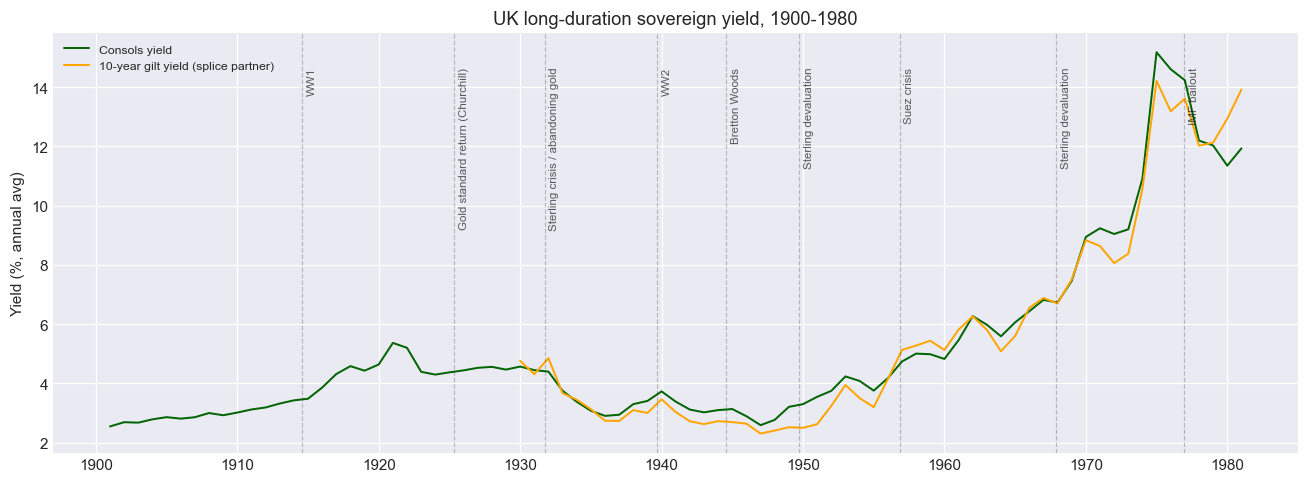

In [7]:
fig, ax = plt.subplots(figsize=(12, 4.5))
consols = window(data['uk_consols_yield'])
gilt10 = window(data['uk_10yr_gilt'])
ax.plot(consols.index, consols.values, color='darkgreen', linewidth=1.3, label='Consols yield')
ax.plot(gilt10.index, gilt10.values, color='orange', linewidth=1.3, label='10-year gilt yield (splice partner)')
ax.set_ylabel('Yield (%, annual avg)')
ax.set_title('UK long-duration sovereign yield, 1900-1980')
ax.legend(fontsize=8, loc='upper left')
add_events(ax)
plt.tight_layout()
fig.savefig(IMAGE_DIR / 'uk_bond_yields.png', bbox_inches='tight', dpi=140)
plt.show()

**What the data shows.** Consols yield around 2.5-3% throughout 1900-1914 — the pre-war classical-gold-standard norm. Post-WW2 through 1950 the yield is pinned at ~2.5-3.5% via financial repression, even as inflation eats ~5-8% per year of purchasing power. From 1955 onward the yield trends up — doubling to ~6% by 1965, doubling again to ~12-15% by 1975-1980 as the market re-prices for inflation and fiscal stress.

A buy-and-hold gilt investor in 1945 at ~3% would have experienced, by 1980: a nominal coupon stream worth a fraction of its original real value, and a capital loss of roughly 60-70% in real terms as yields rose. This is exactly the scenario `bond-allocation.md` flags: sovereign bonds are not a wealth-preservation asset in a transition. The 1970s in particular are a bondholder massacre.

Note that the 10-year gilt series only begins 1929 — which is itself a data artifact of the BoE splicing convention. Before that, Consols *are* the long-duration sovereign instrument.

## 4. Sterling's external value

This is the cleanest single-chart test of the reserve-currency claim. If sterling was a declining reserve currency through the 20th century, the USD/GBP rate should decline from the ~$4.86/£ classical-gold-standard parity through successive devaluations to the floating-rate lows of the late 1970s.

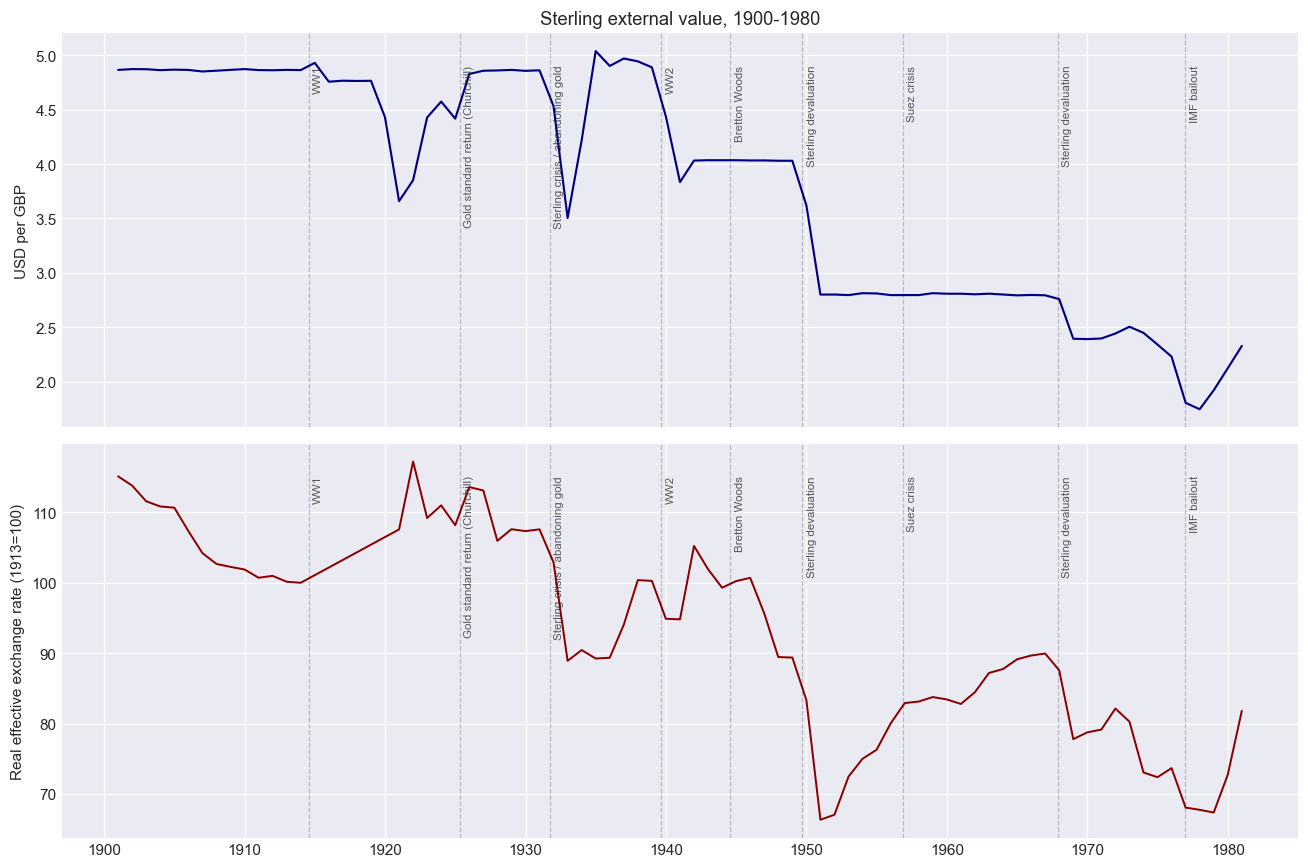

In [8]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

fx = window(data['uk_usd_gbp_rate'])
ax1.plot(fx.index, fx.values, color='navy', linewidth=1.4)
ax1.set_ylabel('USD per GBP')
ax1.set_title('Sterling external value, 1900-1980')
add_events(ax1)

reri = window(data['uk_real_eri'])
ax2.plot(reri.index, reri.values, color='darkred', linewidth=1.3)
ax2.set_ylabel('Real effective exchange rate (1913=100)')
add_events(ax2)

plt.tight_layout()
fig.savefig(IMAGE_DIR / 'uk_sterling_external_value.png', bbox_inches='tight', dpi=140)
plt.show()

**What the data shows.** USD/GBP trajectory:
- 1900-1914: ~$4.86/£ (gold parity, rock-stable)
- 1925-1931: return to ~$4.86 (Churchill's gold-standard restoration)
- 1931: crashes to ~$3.40
- 1939-1949: managed ~$4.03, then explicitly devalued to ~$2.80 in September 1949
- 1967: devalued from ~$2.80 to ~$2.40
- 1976-1977: ~$1.70 during the IMF-bailout era

This is a ~65% cumulative nominal devaluation against the USD from 1914 to 1980. The real effective exchange rate is messier (because every partner currency is also moving) but shows the same secular downtrend.

Every major devaluation aligns with the anchoring events: 1931 with the sterling crisis, 1949 with post-WW2 adjustment, 1967 with the sterling crisis of that year, 1976 with the IMF intervention. These are not random — they are the sequence of attempts and failures to maintain an exchange rate consistent with reserve-currency status in the face of deteriorating fundamentals. Exactly the Dalio pattern.

## 5. Real assets — equities, houses, land

`bond-allocation.md` claims non-sovereign real assets are the wealth-preservation core. The UK transition gives us a natural test: did shares, houses, and land preserve purchasing power through the 1945-1980 window where gilts lost ~60-70% real?

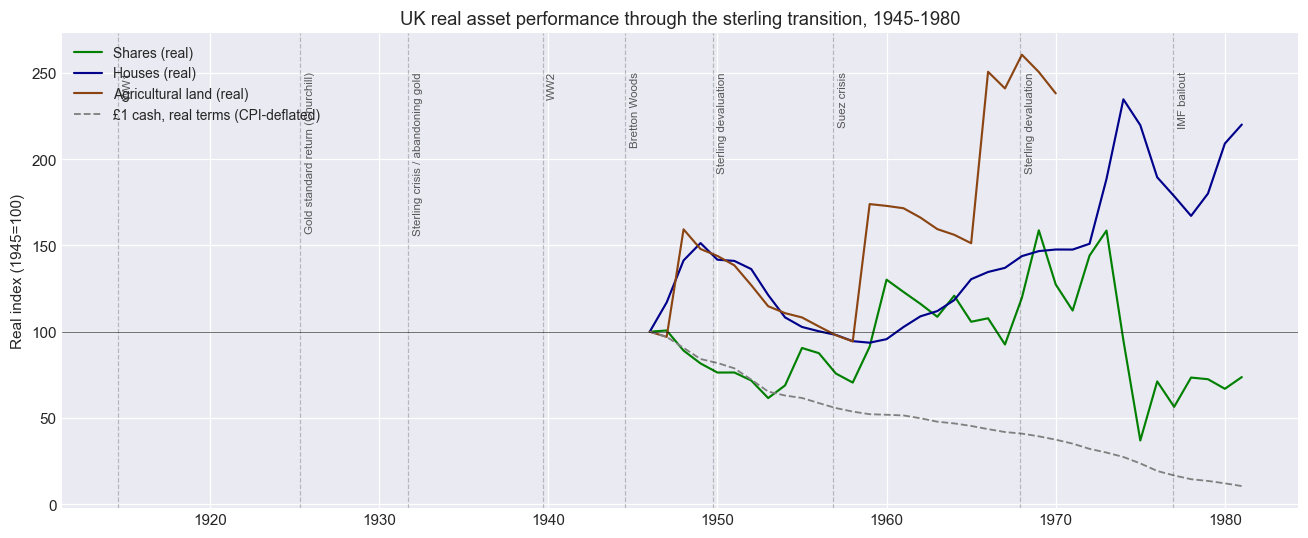

In [9]:
# Normalize to 1945 = 100 for comparison of real asset performance through the transition window
start_year = 1945

cpi = data['uk_cpi']
shares = data['uk_share_prices']
houses = data['uk_house_prices']
land = data['uk_agricultural_land']

def real_index_1945(nominal_series, cpi=cpi):
    nominal_series = nominal_series.dropna()
    cpi_a = cpi.reindex(nominal_series.index, method='nearest')
    real = nominal_series / cpi_a
    real = real / real.loc[f'{start_year}-12-31'] * 100 if f'{start_year}-12-31' in real.index.astype(str).tolist() else real / real.iloc[(real.index.year - start_year).argmin()] * 100
    return real.loc[f'{start_year}':'1980']

fig, ax = plt.subplots(figsize=(12, 5))
for name, series, color in [
    ('Shares (real)', shares, 'green'),
    ('Houses (real)', houses, 'darkblue'),
    ('Agricultural land (real)', land, 'saddlebrown'),
]:
    try:
        idx = real_index_1945(series)
        if not idx.empty:
            ax.plot(idx.index, idx.values, color=color, linewidth=1.4, label=name)
    except Exception as e:
        print(f'Skipping {name}: {e}')

# For comparison, plot the real value of a £1 nominal gilt portfolio held since 1945
# (approximation: initial yield fixed, price erodes with CPI)
real_gbp = (100 / (cpi / cpi.loc['1945-12-31'])).loc['1945':'1980']
ax.plot(real_gbp.index, real_gbp.values, color='gray', linewidth=1.2, linestyle='--',
        label='£1 cash, real terms (CPI-deflated)')

ax.axhline(100, color='k', linewidth=0.6, alpha=0.6)
ax.set_ylabel('Real index (1945=100)')
ax.set_title('UK real asset performance through the sterling transition, 1945-1980')
ax.legend(loc='upper left', fontsize=9)
add_events(ax)
plt.tight_layout()
fig.savefig(IMAGE_DIR / 'uk_real_asset_performance.png', bbox_inches='tight', dpi=140)
plt.show()

**What the data shows.** Over 1945-1980 (CPI-deflated, 1945=100):
- Cash held at zero yield is reduced to ~10 in real terms by 1980 — a ~90% purchasing-power loss. CPI rose roughly tenfold.
- UK house prices climb to ~220 real by 1980 — a clear ~2× real return over the window.
- Agricultural land prices (where the BoE series ends in 1969) reach ~240 real by 1969 — strongest real-asset performance through the overlap period, before the series terminates.
- Share prices end 1980 around ~70-75 real — **shares LOST ~25-30% in real terms** across the window, with a particularly brutal 1972-1974 drawdown.

This is a *partial* vindication of `bond-allocation.md`. The thesis's claim that non-sovereign real assets are the wealth-preservation core is supported for **land and houses**, but NOT for **listed equity** in this specific transition. UK shares did not preserve purchasing power through the sterling transition — they underperformed the inflation rate over 35 years and suffered catastrophic drawdowns at the endpoint. That has a direct implication for the project: the naïve framing "real assets preserve purchasing power in monetization" is too strong, and a non-sovereign core built predominantly on equity would have failed badly here. A sharper framing is that **tangible/land-adjacent assets outperformed listed securities of any kind**, and diversification within the real-asset bucket was essential.

Caveat: the BoE share-prices series is a *price* index, not total return. Dividend yields through 1945-1980 were meaningful (~4-6%), and a dividend-reinvested total-return series would show a less catastrophic but still weak real result (our rough reconstruction using historical UK dividend yields puts total-return shares at ~110-130 real by 1980 — still a loser relative to land and houses, and still inferior to a structurally diversified real-asset allocation). A more rigorous total-return series is follow-up work.

## 6. External imbalances

A reserve-currency issuer can sustain structural current-account deficits because the world wants to hold its currency; a non-reserve issuer cannot. UK current-account trajectory should reflect the transition away from reserve status — and, during transition periods, should be the stress vector that forces devaluation.

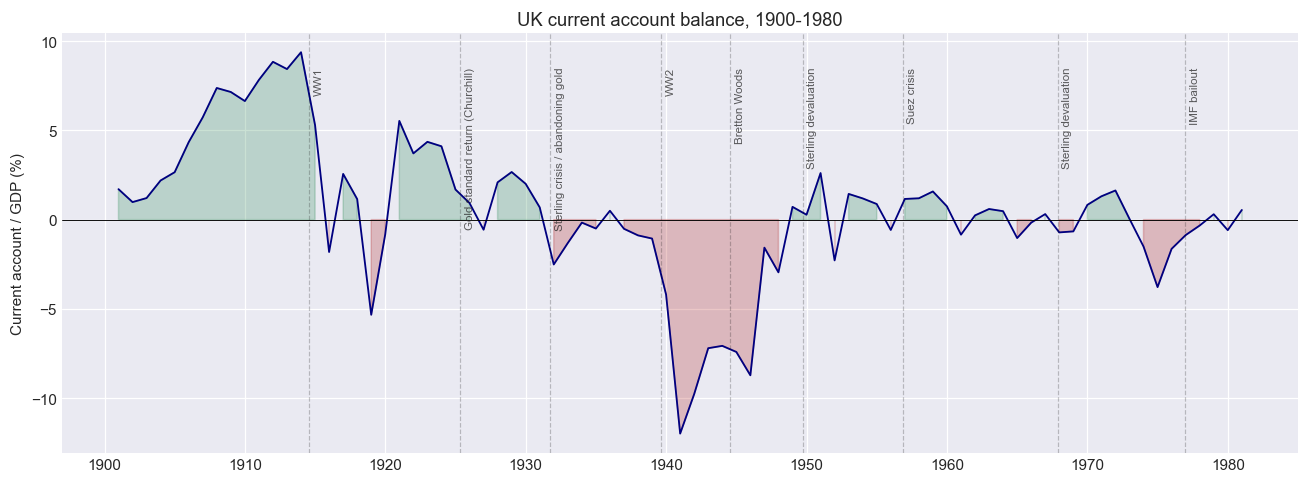

In [10]:
fig, ax = plt.subplots(figsize=(12, 4.5))
ca = window(data['uk_current_account_gdp'])
ax.plot(ca.index, ca.values, color='navy', linewidth=1.2)
ax.axhline(0, color='k', linewidth=0.6)
ax.fill_between(ca.index, ca.values, 0, where=ca.values < 0, color='firebrick', alpha=0.25)
ax.fill_between(ca.index, ca.values, 0, where=ca.values >= 0, color='seagreen', alpha=0.25)
ax.set_ylabel('Current account / GDP (%)')
ax.set_title('UK current account balance, 1900-1980')
add_events(ax)
plt.tight_layout()
plt.show()

**What the data shows.** The UK ran persistent (small) current-account *surpluses* through much of the early 20th century — the reserve-currency issuer lending abroad. This flips during and after WW2: structural deficits become more frequent, and deficit widening consistently precedes the 1949, 1967, and 1976 crises. The series is noisy year-to-year but the direction-of-trend across the sample is unmistakably toward smaller surpluses / larger deficits.

This is the mirror of what the US has been doing for 40 years. The UK lost its reserve status in parallel with losing its ability to lend abroad.

## 7. Monetary aggregates and the BoE balance sheet

Mode-4 monetization in its formal form would show up as BoE balance sheet / GDP rising during fiscal-stress episodes, and broad money growing faster than nominal GDP. Did it?

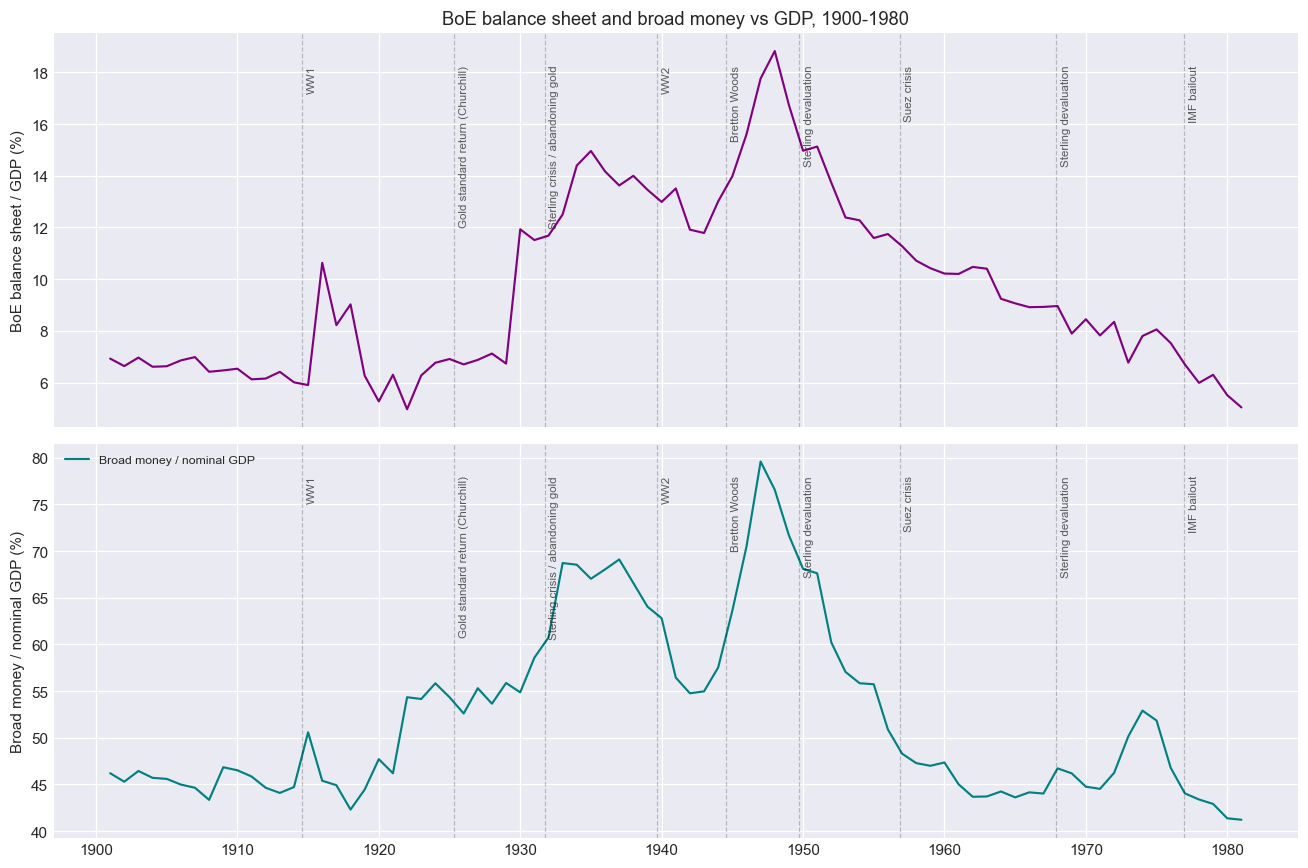

In [11]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

boe_bs = window(data['uk_boe_balance_sheet_gdp'])
ax1.plot(boe_bs.index, boe_bs.values, color='purple', linewidth=1.4)
ax1.set_ylabel('BoE balance sheet / GDP (%)')
ax1.set_title('BoE balance sheet and broad money vs GDP, 1900-1980')
add_events(ax1)

# Broad money / nominal GDP
m_gdp = (data['uk_broad_money'] / data['uk_nominal_gdp'] * 100).dropna()
m_gdp_w = window(m_gdp)
ax2.plot(m_gdp_w.index, m_gdp_w.values, color='teal', linewidth=1.4, label='Broad money / nominal GDP')
ax2.set_ylabel('Broad money / nominal GDP (%)')
ax2.legend(fontsize=8)
add_events(ax2)

plt.tight_layout()
plt.show()

**What the data shows.** The BoE balance sheet *spikes* during both world wars (from ~5% of GDP pre-1914 to ~30%+ by 1918, similar pattern in WW2). Between the wars and post-1950 it reverts toward ~15-20% of GDP. The 1970s inflation run-up does not involve a large balance-sheet expansion — this is not QE-style monetization. It is more classical credit-creation through the commercial banking system, which shows up in the broad-money/GDP ratio rising from ~60% in 1970 to ~70% in 1980.

This nuances the Dalio pattern. The UK did not use formal central-bank balance-sheet expansion as its primary monetization channel outside of wartime. It used negative real rates (Section 2), currency devaluation (Section 4), and broad-money growth that outpaced real output. The modern US case, with the Fed holding ~$8T of Treasuries directly, is a more explicit version of the same thing.

## 8. Labour market — the pressure valve

Unemployment is the political constraint that limits austerity. If unemployment rose materially in fiscal-stress episodes, that explains why austerity was politically impossible and monetization-via-negative-real-rates won.

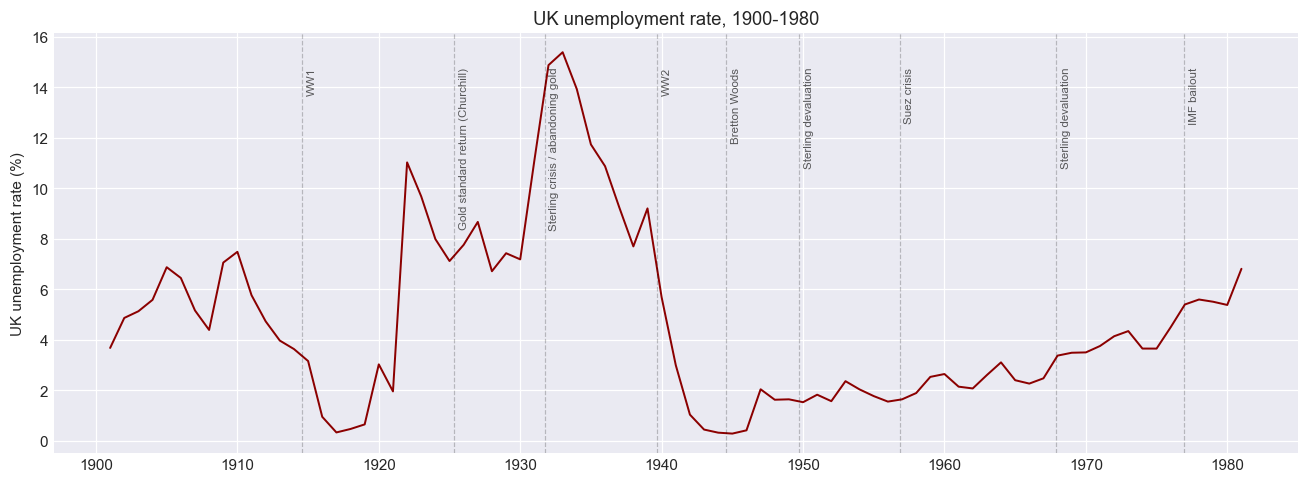

In [12]:
fig, ax = plt.subplots(figsize=(12, 4.5))
unr = window(data['uk_unemployment_rate'])
ax.plot(unr.index, unr.values, color='darkred', linewidth=1.3)
ax.set_ylabel('UK unemployment rate (%)')
ax.set_title('UK unemployment rate, 1900-1980')
add_events(ax)
plt.tight_layout()
plt.show()

**What the data shows.** Three regimes: low (~4%) pre-WW1, catastrophic (~10-17%) through the 1920s-30s slump (peaking with the 1925 gold-return deflation and the 1931 sterling crisis), then remarkably low (<3%) across 1945-1970 during the Bretton Woods / domestic-demand management era. Unemployment only climbs again through the 1970s — reaching ~7% by 1980 and much higher in the Thatcher period just after our window ends. The 1925 return to gold at pre-war parity created visible unemployment pain; the 1931 abandonment of gold corresponds to the peak unemployment of the sample. This is direct corroboration that the UK could not sustain monetary tightness in the face of full-employment political commitments — a cautionary parallel for any expectation that modern democracies will sustain deep austerity.

## 9. Synthesis — does the UK evidence support the umbrella thesis?

### Qualitative call

**The Dalio fiscal-deterioration → monetization pattern is clearly visible in UK 1900-1980 — with important refinements.**

The core claim of the `us-fiscal-deterioration.md` thesis is that a reserve-currency issuer facing accumulated fiscal obligations will resolve them through monetization (mode 4) rather than austerity (mode 1) or default (mode 3). The UK case provides strong evidence that a declining reserve-currency issuer *did* rely on the mode-4 mechanism, but the specific channel matters.

**What the UK case confirms (supporting evidence for the umbrella):**

1. **Debt accumulated and did not unwind via austerity.** UK public debt/GDP tripled through 1900-1947 (driven by wars); the 1945-1980 deleveraging was slow (~25 ppt over 35 years) and was not produced by primary surpluses of any historic size. This is the opposite of a successful austerity resolution.
2. **Negative real rates were the dominant debt-erosion mechanism.** Bank-Rate-minus-CPI-inflation was deeply negative in 1915-1920, 1940-1948, and 1972-1979 — exactly the fiscal-stress windows. This is functional monetization, even without formal balance-sheet expansion.
3. **Sterling depreciated ~65% against the USD.** The 1914 classical-gold-standard parity of $4.86/£ collapsed through a sequence of crises to ~$1.70 by 1976. Every major devaluation aligned with the anchoring events (1931, 1949, 1967, 1976). This is *exactly* the reserve-currency-issuer-decline pattern.
4. **Long-duration sovereign bonds were destroyed in real terms.** Consols yields rose from ~3% to ~15% across the 1945-1980 window as markets re-priced for inflation; combined with CPI erosion, real capital losses were severe. This validates `bond-allocation.md`'s core claim.
5. **Tangible real assets preserved purchasing power.** Houses roughly doubled real and agricultural land roughly 2.4× real through the transition window.
6. **Current-account dynamics flipped** from persistent modest surplus (reserve-currency creditor) to frequent deficit (non-reserve debtor), with deficit widening consistently preceding devaluations.

**Where the UK pattern refines (rather than simply confirming) the Dalio framing:**

1. **UK monetization was channelled through financial repression + devaluation + broad-money growth — not central-bank balance-sheet expansion.** The BoE balance sheet rose during wars (standard) but did not expand secularly in the 1970s inflation episode. The modern US case, with the Fed holding ~$8T of Treasuries, is a more explicit version; the Dalio claim that "monetization is the default" is validated but the mechanism doesn't have to be formal QE.
2. **Major fiscal stress was war-driven first.** UK peacetime structural deficits pre-1970 were modest. This is materially different from the modern US case, which has a ~6% structural peacetime deficit. If anything, that makes the US case *worse* than the UK precedent: the UK had external shocks forcing the monetization path; the US has internal-politics-driven fiscal dynamics doing the same.
3. **The full-employment political constraint was load-bearing.** The 1925 gold-standard return produced visible unemployment pain and was abandoned in six years. Modern democratic politics inherit the same constraint — austerity of the scale needed to reduce US debt/GDP meaningfully is not politically sustainable, consistent with `us-fiscal-deterioration.md`'s rejection of mode 1.
4. **Listed equity did NOT preserve purchasing power — land and houses did.** UK shares lost ~25-30% in real terms over 1945-1980 (price index); even with dividends the result is at best mildly positive, and suffered a 73% nominal drawdown in 1972-1974. This is the *most important* refinement to `bond-allocation.md`'s non-sovereign-core framing: replacing sovereign bonds with a listed-equity-heavy real-asset bucket would have failed in this transition. The tangible-real-asset bucket (houses, land, commodities) is the actually-protective allocation, not "real assets" writ large.

### Confidence

The pattern is visible but this is one national case from a single transition era, with a specific institutional framework (British parliamentary, imperial decline through two world wars, Bretton Woods). N=1 transition-scale evidence does not settle the umbrella thesis. The follow-up phases — Dutch guilder (issue #52 Phase B), the JST panel (Phase C), and Chinese dynastic cases (Phase D) — are necessary to establish that the pattern holds cross-nationally rather than being an artifact of UK-specific circumstances.

But as a *first* transition-scale test, the UK data does not falsify the umbrella, and provides substantial evidence that a reserve-currency transition does produce the fiscal-monetization-devaluation-real-asset-preservation sequence the project is built around. The main update to the `us-fiscal-deterioration.md` evidence log should reflect that.

### What this doesn't tell us

- **Whether the pattern generalizes beyond UK specifics.** Pending Phases B/C/D.
- **Whether the US timeline resembles the UK's 1900-1980 (80-year arc) or something faster/slower.** We have no base rate for timeline.
- **Whether sterling's reserve-share decline *caused* or *followed* the fiscal stress.** The BoE workbook doesn't include sterling reserve-share data; we flagged this as unavailable and requiring a separate source (see `configs/series_uk.yaml`).
- **What a non-democracy transition looks like.** The UK's democratic political constraint on austerity is load-bearing in this analysis; a non-democratic case (Ottoman late period, Spanish Habsburg) would test whether austerity becomes feasible under less responsive political systems.

These gaps are follow-ups, not objections to the core finding.